# Probability Paths in Flow Matching

A **probability path** $p_t(\mathbf{x}_t \mid \mathbf{x}_0, \mathbf{x}_1)$ defines how the
model finds where $\mathbf{x}_t$ between source $\mathbf{x}_0$ and target $\mathbf{x}_1$ during training.
Every path produces an intermediate state at time $t \in [0,1]$:

$$\mathbf{x}_t = \mu_t(\mathbf{x}_0, \mathbf{x}_1) + \sigma_t\,\boldsymbol{\epsilon}$$

Each path class exposes four methods:

| Method | Returns |
|---|---|
| `compute_mu_t(t, x0, x1)` | Mean $\mu_t$ |
| `compute_sigma_t(t)` | Noise std $\sigma_t$ |
| `compute_xt(t, x0, x1)` | Find position $\mathbf{x}_t$ at time t |
| `compute_ut(t, xt, x0, x1)` | Find velocity $u_t$ at time t |

**Summary of all four paths:**

| Path | $\mu_t$ | $\sigma_t$ | Stochastic | Parameters |
|---|---|---|---|---|
| `LinearDiracProbabilityPath` | $(1-t)\mathbf{x}_0 + t\mathbf{x}_1$ | $0$ | No | `sigma` (ignored) |
| `LinearGaussianProbabilityPath` | $(1-t)\mathbf{x}_0 + t\mathbf{x}_1$ | $\sigma$ | Yes | `sigma` |
| `SchrodingerBridgeProbabilityPath` | $(1-t)\mathbf{x}_0 + t\mathbf{x}_1$ | $\sigma\sqrt{t(1-t)}$ | Yes | `sigma`, `eps` |
| `VariancePreservingDiracProbabilityPath` | $\cos(\tfrac{\pi t}{2})\mathbf{x}_1 + \sin(\tfrac{\pi t}{2})\mathbf{x}_0$ | $0$ | No | `sigma` (ignored) |


## Contents

**1.** Data: Two-Moons Transport Task  
**2.** `LinearDiracProbabilityPath`  
**3.** `LinearGaussianProbabilityPath`  
**4.** `SchrodingerBridgeProbabilityPath`  
**5.** `VariancePreservingDiracProbabilityPath`  
**6.** Side-by-Side Comparison with SCFlow  
**7.** Custom Path: Stochastic Interpolant  
**8.** References  



In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import anndata as ad

from sc_flow.backends.torch.probability_paths import (
    LinearGaussianProbabilityPath,
    LinearDiracProbabilityPath,
    SchrodingerBridgeProbabilityPath,
    VariancePreservingDiracProbabilityPath,
)
from sc_flow.dataset.toy_data import get_toy_dataset
from sc_flow import SCFlow

torch.manual_seed(7)

## Data: Two-Moons Transport Task

A 2-D transport problem: move cells from the *bottom* moon (source $\mathbf{x}_0$)
to the *top* moon (target $\mathbf{x}_1$).  The pair $(\mathbf{x}_0, \mathbf{x}_1)$
defines one training sample.  In this notebook, we will show hows the four paths are applied to this dataset.


In [3]:
adata = get_toy_dataset("moons", n_samples=5000, noise=0.1, random_state=42).adata
X = np.array(adata.X, dtype=np.float32)
labels = np.array(adata.obsm["Y"]).ravel()

bottom_moon_X = torch.tensor(X[labels == "1"], dtype=torch.float32)  # source  x0
top_moon_X = torch.tensor(X[labels == "0"], dtype=torch.float32)  # target  x1

print(f"Source (bottom moon): {bottom_moon_X.shape}")
print(f"Target (top moon):    {top_moon_X.shape}")

Source (bottom moon): torch.Size([2500, 2])
Target (top moon):    torch.Size([2500, 2])


---
## 1. LinearDiracProbabilityPath

The simplest possible path: a **deterministic straight line** from source to target
with no added noise.

**Linear interpolation**

$$\mu_t(\mathbf{x}_0, \mathbf{x}_1) = (1-t)\,\mathbf{x}_0 + t\,\mathbf{x}_1$$

**Noise standard deviation**

$$\sigma_t = 0 \quad \text{(no noise at any } t \text{)}$$

**Conditional velocity field**

$$u_t(\mathbf{x}_t \mid \mathbf{x}_0, \mathbf{x}_1) = \mathbf{x}_1 - \mathbf{x}_0$$

The velocity is **constant in time**.

**Parameters**

| Parameter | Type | Default | Description |
|---|---|---|---|
| `sigma` | `float` | `0.0` | Accepted but **ignored** — `compute_sigma_t` always returns 0 regardless of this value. |

> **References:** \[1\] Lipman et al. (2022) · \[2\] Liu et al. (2022)


In [ ]:
# Time points
t_vals = torch.tensor(np.linspace(0, 1, 200), dtype=torch.float32)
T_STEPS = torch.linspace(0, 1, 50)

# Path
path_ld = LinearDiracProbabilityPath()

# sigma_t. Always returns zeroes
sigma_t_ld = path_ld.compute_sigma_t(t_vals).numpy()

# Mean trajectories for 6 (source, target) pairs
n_pairs = 6
src_idx = torch.randperm(len(bottom_moon_X))[:n_pairs]  # 6 random points from the source dist
tgt_idx = torch.randperm(len(top_moon_X))[:n_pairs]  # 6 random points from the target dist
x0_batch_ld = bottom_moon_X[src_idx]  # Coords of the 6 source points
x1_batch_ld = top_moon_X[tgt_idx]  # Coords of the 6 target points

# Compute mean trajectories for the 6 pairs for 50 time steps
trajs_ld = []
for i in range(n_pairs):
    x0i, x1i = x0_batch_ld[i : i + 1], x1_batch_ld[i : i + 1]
    traj = []
    for t in T_STEPS:
        mu_t = path_ld.compute_mu_t(t * torch.ones(1), x0i, x1i)
        traj.append(mu_t.numpy()[0])
    trajs_ld.append(np.stack(traj))

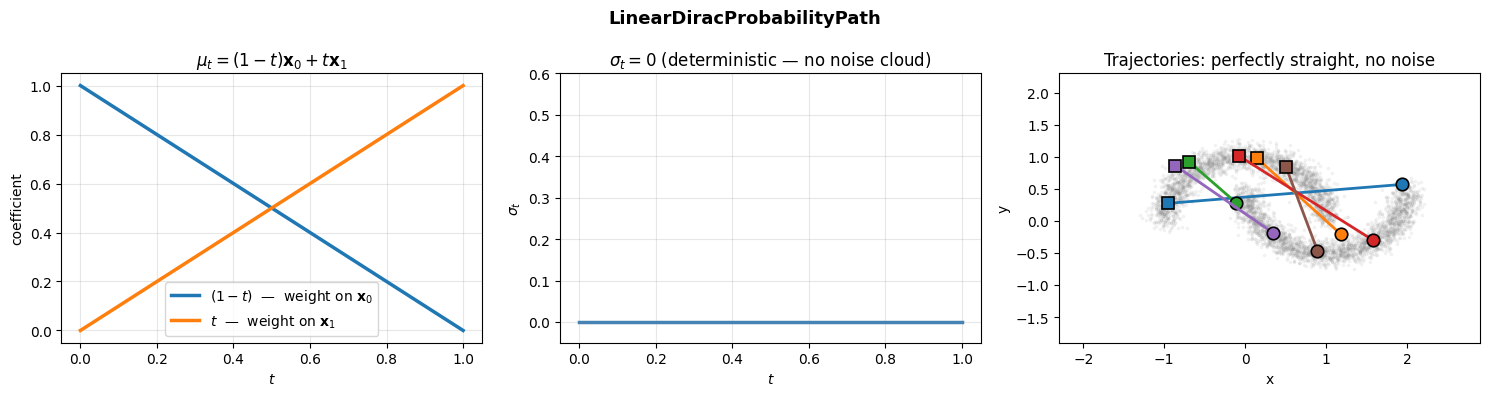

In [ ]:
PAIR_COLORS = [plt.cm.tab10(i / 10) for i in range(n_pairs)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot showing weights for x0 and x1
coeff_x0_ld = 1 - t_vals
coeff_x1_ld = t_vals
axes[0].plot(t_vals, coeff_x0_ld, lw=2.5, color="tab:blue", label=r"$(1-t)$  —  weight on $\mathbf{x}_0$")
axes[0].plot(t_vals, coeff_x1_ld, lw=2.5, color="tab:orange", label=r"$t$  —  weight on $\mathbf{x}_1$")
axes[0].set_xlabel("$t$")
axes[0].set_ylabel("coefficient")
axes[0].set_title(r"$\mu_t = (1-t)\mathbf{x}_0 + t\mathbf{x}_1$")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot showing sigma_t (noise level)
axes[1].plot(t_vals, sigma_t_ld, lw=2.5, color="steelblue")
axes[1].set_ylim(-0.05, 0.6)
axes[1].set_xlabel("$t$")
axes[1].set_ylabel(r"$\sigma_t$")
axes[1].set_title(r"$\sigma_t = 0$ (deterministic — no noise cloud)")
axes[1].grid(alpha=0.3)

# Plot showing trajectories for the 6 pairs
axes[2].scatter(bottom_moon_X[:, 0], bottom_moon_X[:, 1], s=3, alpha=0.07, color="gray")
axes[2].scatter(top_moon_X[:, 0], top_moon_X[:, 1], s=3, alpha=0.07, color="gray")
for i, traj in enumerate(trajs_ld):
    color = PAIR_COLORS[i]
    axes[2].plot(traj[:, 0], traj[:, 1], "-", color=color, lw=2)
    axes[2].plot(*x0_batch_ld[i].numpy(), "o", color=color, ms=9, markeredgecolor="k", mew=1.2)
    axes[2].plot(*x1_batch_ld[i].numpy(), "s", color=color, ms=9, markeredgecolor="k", mew=1.2)
axes[2].set_xlim(-2.3, 2.9)
axes[2].set_ylim(-1.9, 2.3)
axes[2].set_title("Trajectories: perfectly straight, no noise")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")

plt.suptitle("LinearDiracProbabilityPath", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 2. LinearGaussianProbabilityPath

Adds **constant Gaussian noise** on top of the linear interpolation.  The mean is
identical to `LinearDiracProbabilityPath`; the difference is a non-zero $\sigma_t$.

**Linear interpolation**

$$\mu_t(\mathbf{x}_0, \mathbf{x}_1) = (1-t)\,\mathbf{x}_0 + t\,\mathbf{x}_1$$

**Noise standard deviation**

$$\sigma_t = \sigma \quad \text{(constant at every } t \text{)}$$

**Conditional velocity field**

$$u_t(\mathbf{x}_t \mid \mathbf{x}_0, \mathbf{x}_1) = \mathbf{x}_1 - \mathbf{x}_0$$

The velocity is **still constant** — the noise samples $\mathbf{x}_t$ during training
but does not change the target the network must predict.

**Parameters**

| Parameter | Type | Default | Description |
|---|---|---|---|
| `sigma` | `float` | *required* | Noise level $\sigma > 0$. Controls the constant-width cloud around the straight-line mean. Larger $\sigma$ regularises more but makes the loss noisier. |

> **References:** \[1\] Lipman et al. (2022) · \[3\] Tong et al. (2023, CFM)


In [ ]:
SIGMAS_LG = [0.1, 0.3]  # Linear Gaussian sigma values
t_vals = np.linspace(0, 1, 200)
T_STEPS = torch.linspace(0, 1, 50)
N_SAMPLES = 80
ground_sigma = 0.1

# Calculate sigma_t for all sigma values
_t = torch.tensor(t_vals, dtype=torch.float32)
sigma_t_lg = {}
for sigma in SIGMAS_LG:
    path = LinearGaussianProbabilityPath(sigma=sigma, prng=torch.Generator())
    sigma_t_lg[sigma] = path.compute_sigma_t(_t).numpy()


# Single (x0, x1) pair for cloud visualization
x0_single_lg = bottom_moon_X[0:1]
x1_single_lg = top_moon_X[0:1]
clouds_single_lg = {}
for sigma in SIGMAS_LG:
    path = LinearGaussianProbabilityPath(sigma=sigma, prng=torch.Generator())
    samples = []
    for t in T_STEPS:  # Compute 80 samples cloud at each time step for the single (x0, x1) pair
        for _ in range(N_SAMPLES):
            xt = path.compute_xt(t * torch.ones(1), x0_single_lg, x1_single_lg)
            samples.append(xt.detach().numpy()[0])
    clouds_single_lg[sigma] = np.stack(samples)


# Mean trajectories + clouds for 6 pairs (sigma=0.1)
n_pairs = 6
src_idx = torch.randperm(len(bottom_moon_X))[:n_pairs]
tgt_idx = torch.randperm(len(top_moon_X))[:n_pairs]
x0_batch_lg = bottom_moon_X[src_idx]
x1_batch_lg = top_moon_X[tgt_idx]
path_lg = LinearGaussianProbabilityPath(sigma=ground_sigma, prng=torch.Generator())
mean_traj_single_lg = np.stack(
    [path_lg.compute_mu_t(t * torch.ones(1), x0_single_lg, x1_single_lg).numpy()[0] for t in T_STEPS]
)

trajs_lg, clouds_traj_lg = [], []
for i in range(n_pairs):
    x0i, x1i = x0_batch_lg[i : i + 1], x1_batch_lg[i : i + 1]
    trajs_lg.append(np.array([path_lg.compute_mu_t(t * torch.ones(1), x0i, x1i).numpy()[0] for t in T_STEPS]))
    clouds_traj_lg.append(
        np.array(
            [path_lg.compute_xt(t * torch.ones(1), x0i, x1i).detach().numpy()[0] for t in T_STEPS for _ in range(40)]
        )
    )

The probability path  LinearGaussianProbabilityPath requires a PRNG. Please provide an instance of `torch.Generator`for reproducible results. Setting it to \`torch.random.default_generator\` by default.


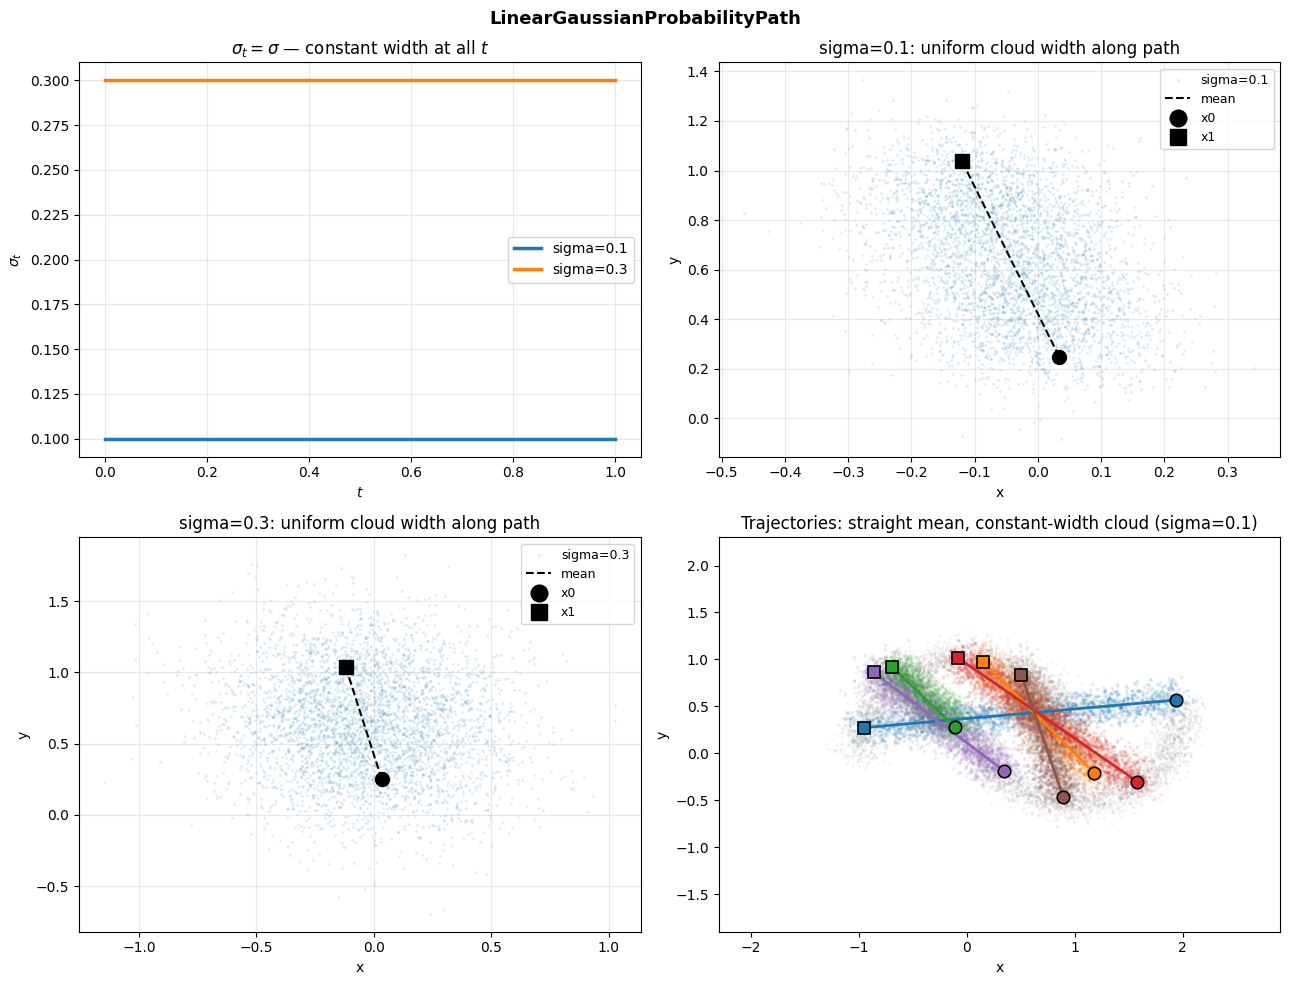

In [ ]:
PAIR_COLORS = [plt.cm.tab10(i / 10) for i in range(n_pairs)]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()

# Plot showing sigma_t for different sigma values
for sigma in SIGMAS_LG:
    axes[0].plot(t_vals, sigma_t_lg[sigma], lw=2.5, label=f"sigma={sigma}")
axes[0].set_xlabel("$t$")
axes[0].set_ylabel(r"$\sigma_t$")
axes[0].set_title(r"$\sigma_t = \sigma$ — constant width at all $t$")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plots showing clouds + mean trajectory for the single (x0, x1) pair for each sigma
for ax, sigma in zip(axes[1:3], SIGMAS_LG, strict=False):
    ax.scatter(
        clouds_single_lg[sigma][:, 0],
        clouds_single_lg[sigma][:, 1],
        s=4,
        alpha=0.15,
        linewidths=0,
        label=f"sigma={sigma}",
    )
    ax.plot(mean_traj_single_lg[:, 0], mean_traj_single_lg[:, 1], "k--", lw=1.5, label="mean")
    ax.plot(*x0_single_lg.numpy()[0], "o", color="k", ms=10, markeredgecolor="k", zorder=5, label="x0")
    ax.plot(*x1_single_lg.numpy()[0], "s", color="k", ms=10, markeredgecolor="k", zorder=5, label="x1")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"sigma={sigma}: uniform cloud width along path")
    ax.legend(fontsize=9, markerscale=1.2)
    ax.grid(alpha=0.3)

# Plot showing trajectories for the 6 pairs (sigma=0.1)
axes[3].scatter(bottom_moon_X[:, 0], bottom_moon_X[:, 1], s=2, alpha=0.05, color="gray")
axes[3].scatter(top_moon_X[:, 0], top_moon_X[:, 1], s=2, alpha=0.05, color="gray")
for i in range(n_pairs):
    color = PAIR_COLORS[i]
    axes[3].scatter(clouds_traj_lg[i][:, 0], clouds_traj_lg[i][:, 1], s=6, color=color, alpha=0.15, linewidths=0)
    axes[3].plot(trajs_lg[i][:, 0], trajs_lg[i][:, 1], "-", color=color, lw=2, zorder=3)
    axes[3].plot(*x0_batch_lg[i].numpy(), "o", color=color, ms=9, markeredgecolor="k", mew=1.2, zorder=5)
    axes[3].plot(*x1_batch_lg[i].numpy(), "s", color=color, ms=9, markeredgecolor="k", mew=1.2, zorder=5)
axes[3].set_xlim(-2.3, 2.9)
axes[3].set_ylim(-1.9, 2.3)
axes[3].set_title("Trajectories: straight mean, constant-width cloud (sigma=0.1)")
axes[3].set_xlabel("x")
axes[3].set_ylabel("y")

plt.suptitle("LinearGaussianProbabilityPath", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 3. SchrodingerBridgeProbabilityPath

The **Schrödinger Bridge** path shares the same linear mean as the two paths
above but uses a **time-varying noise** that vanishes at both endpoints.

**Linear interpolation**

$$\mu_t(\mathbf{x}_0, \mathbf{x}_1) = (1-t)\,\mathbf{x}_0 + t\,\mathbf{x}_1$$

**Noise standard deviation**

$$\sigma_t = \sigma\,\sqrt{t\,(1-t)}$$

The noise profile is a bell curve peaking at $t = \tfrac{1}{2}$ with
$\sigma_{1/2} = \tfrac{\sigma}{2}$, and $\sigma_0 = \sigma_1 = 0$.

**Conditional velocity field**

$$u_t(\mathbf{x}_t \mid \mathbf{x}_0, \mathbf{x}_1)
  = \frac{1-2t}{2t(1-t)+\varepsilon}\left(\mathbf{x}_t - \mu_t\right)
    + \mathbf{x}_1 - \mathbf{x}_0$$

Unlike the linear paths, $u_t$ depends on $\mathbf{x}_t$ itself: the first term
"corrects" for the current noise level and ensures the sampled $\mathbf{x}_t$
arrives exactly at $\mathbf{x}_1$ by $t = 1$.

**Parameters**

| Parameter | Type | Default | Description |
|---|---|---|---|
| `sigma` | `float` | *required* | Controls peak noise at the midpoint: $\sigma_{1/2} = \sigma/2$. |
| `eps` | `float` | `1e-35` | Added to the denominator $2t(1-t)$ to avoid division by zero near $t=0$ and $t=1$. Only change this if you observe numerical instability. |

> **References:** \[3\] Tong et al. (2023, CFM) · \[4\] Tong et al. (2023, SFBM)


In [22]:
SIGMAS_SB = [0.05, 0.3, 0.6, 1.0]
t_vals = np.linspace(0, 1, 200)
T_STEPS = torch.linspace(0, 1, 50)
N_SAMPLES = 80
_t = torch.tensor(t_vals, dtype=torch.float32)

# sigma_t for each SB sigma, plus LinearGaussian as reference
sigma_t_sb = {}
for sigma in SIGMAS_SB:
    path = SchrodingerBridgeProbabilityPath(sigma=sigma, prng=torch.Generator())
    sigma_t_sb[sigma] = path.compute_sigma_t(_t).numpy()

sigma_t_lg_ref = LinearGaussianProbabilityPath(sigma=0.3, prng=torch.Generator()).compute_sigma_t(_t).numpy()

# Single (x0, x1) pair for cloud visualization
x0_single_sb = bottom_moon_X[0:1]
x1_single_sb = top_moon_X[0:1]

path_sb = SchrodingerBridgeProbabilityPath(sigma=0.1, prng=torch.Generator())

mean_traj_single_sb = np.stack(
    [path_sb.compute_mu_t(t * torch.ones(1), x0_single_sb, x1_single_sb).numpy()[0] for t in T_STEPS]
)

clouds_single_sb = {}
for sigma in SIGMAS_SB:
    path = SchrodingerBridgeProbabilityPath(sigma=sigma, prng=torch.Generator())
    samples = []
    for t in T_STEPS:
        for _ in range(N_SAMPLES):
            xt = path.compute_xt(t * torch.ones(1), x0_single_sb, x1_single_sb)
            samples.append(xt.detach().numpy()[0])
    clouds_single_sb[sigma] = np.stack(samples)

# Mean trajectories + clouds for 6 pairs (sigma=0.1)
n_pairs = 6
src_idx = torch.randperm(len(bottom_moon_X))[:n_pairs]
tgt_idx = torch.randperm(len(top_moon_X))[:n_pairs]
x0_batch_sb = bottom_moon_X[src_idx]
x1_batch_sb = top_moon_X[tgt_idx]

trajs_sb, clouds_traj_sb = [], []
for i in range(n_pairs):
    x0i, x1i = x0_batch_sb[i : i + 1], x1_batch_sb[i : i + 1]

    traj = []
    for t in T_STEPS:
        mu_t = path_sb.compute_mu_t(t * torch.ones(1), x0i, x1i)
        traj.append(mu_t.numpy()[0])
    trajs_sb.append(np.stack(traj))

    cloud = []
    for t in T_STEPS:
        for _ in range(40):
            xt = path_sb.compute_xt(t * torch.ones(1), x0i, x1i)
            cloud.append(xt.detach().numpy()[0])
    clouds_traj_sb.append(np.stack(cloud))

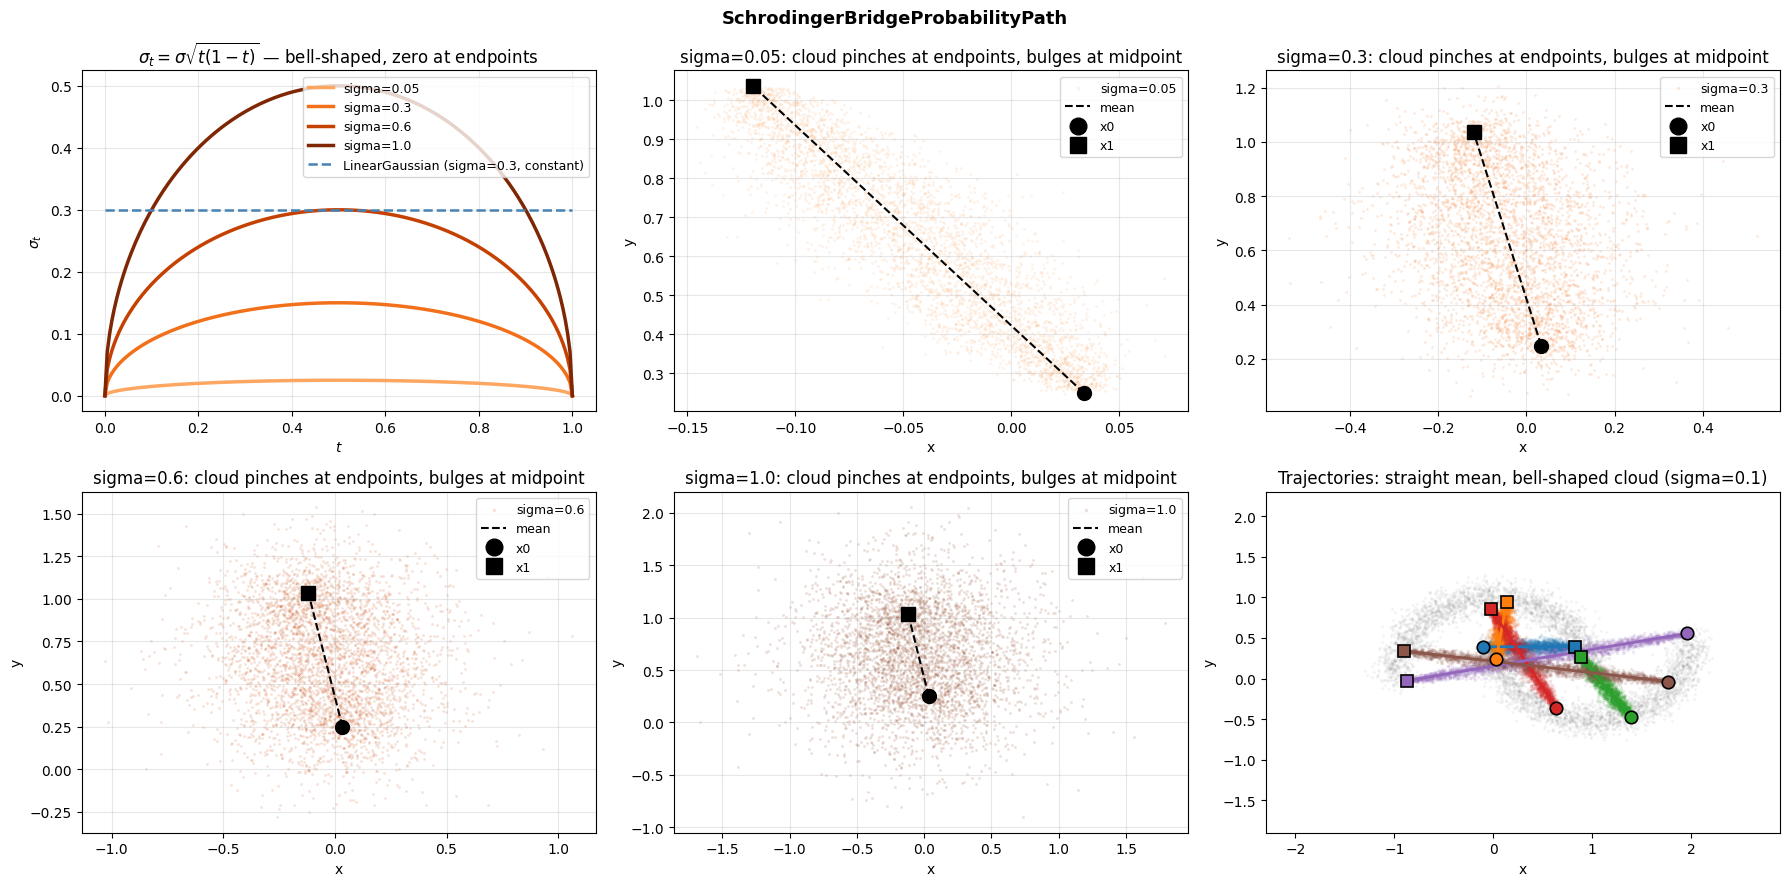

In [23]:
PAIR_COLORS = [plt.cm.tab10(i / 10) for i in range(n_pairs)]
colors = plt.cm.Oranges(np.linspace(0.4, 1.0, len(SIGMAS_SB)))

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

for sigma, c in zip(SIGMAS_SB, colors, strict=False):
    axes[0].plot(t_vals, sigma_t_sb[sigma], lw=2.5, color=c, label=f"sigma={sigma}")
axes[0].plot(
    t_vals, sigma_t_lg_ref, lw=1.8, color="steelblue", linestyle="--", label="LinearGaussian (sigma=0.3, constant)"
)
axes[0].set_xlabel("$t$")
axes[0].set_ylabel(r"$\sigma_t$")
axes[0].set_title(r"$\sigma_t = \sigma\sqrt{t(1-t)}$ — bell-shaped, zero at endpoints")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

for ax, sigma, c in zip(axes[1:5], SIGMAS_SB, colors, strict=False):
    ax.scatter(
        clouds_single_sb[sigma][:, 0],
        clouds_single_sb[sigma][:, 1],
        s=4,
        color=c,
        alpha=0.15,
        linewidths=0,
        label=f"sigma={sigma}",
    )
    ax.plot(mean_traj_single_sb[:, 0], mean_traj_single_sb[:, 1], "k--", lw=1.5, label="mean")
    ax.plot(*x0_single_sb.numpy()[0], "o", color="k", ms=10, markeredgecolor="k", zorder=5, label="x0")
    ax.plot(*x1_single_sb.numpy()[0], "s", color="k", ms=10, markeredgecolor="k", zorder=5, label="x1")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"sigma={sigma}: cloud pinches at endpoints, bulges at midpoint")
    ax.legend(fontsize=9, markerscale=1.2)
    ax.grid(alpha=0.3)

axes[5].scatter(bottom_moon_X[:, 0], bottom_moon_X[:, 1], s=2, alpha=0.05, color="gray")
axes[5].scatter(top_moon_X[:, 0], top_moon_X[:, 1], s=2, alpha=0.05, color="gray")
for i in range(n_pairs):
    color = PAIR_COLORS[i]
    axes[5].scatter(clouds_traj_sb[i][:, 0], clouds_traj_sb[i][:, 1], s=6, color=color, alpha=0.15, linewidths=0)
    axes[5].plot(trajs_sb[i][:, 0], trajs_sb[i][:, 1], "-", color=color, lw=2, zorder=3)
    axes[5].plot(*x0_batch_sb[i].numpy(), "o", color=color, ms=9, markeredgecolor="k", mew=1.2, zorder=5)
    axes[5].plot(*x1_batch_sb[i].numpy(), "s", color=color, ms=9, markeredgecolor="k", mew=1.2, zorder=5)
axes[5].set_xlim(-2.3, 2.9)
axes[5].set_ylim(-1.9, 2.3)
axes[5].set_title("Trajectories: straight mean, bell-shaped cloud (sigma=0.1)")
axes[5].set_xlabel("x")
axes[5].set_ylabel("y")

plt.suptitle("SchrodingerBridgeProbabilityPath", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 4. VariancePreservingDiracProbabilityPath

A **deterministic path with a cosine interpolation blend**.  Instead of the
linear weights $(1-t)$ and $t$, the mean uses $\sin$ and $\cos$ coefficients that
trace a quarter-circle arc in coefficient space. n the method, there is no ditortion of the length of the path at any point.

**cosine interpolation**

$$\mu_t(\mathbf{x}_0, \mathbf{x}_1)
  = \cos\!\left(\tfrac{\pi t}{2}\right)\mathbf{x}_1
  + \sin\!\left(\tfrac{\pi t}{2}\right)\mathbf{x}_0$$

**Noise standard deviation**

$$\sigma_t = 0$$

**Conditional velocity field**

$$u_t = -\tfrac{\pi}{2}\sin\!\left(\tfrac{\pi t}{2}\right)\mathbf{x}_1
       + \tfrac{\pi}{2}\cos\!\left(\tfrac{\pi t}{2}\right)\mathbf{x}_0$$

**Parameters**

| Parameter | Type | Default | Description |
|---|---|---|---|
| `sigma` | `float` | `0.0` | Accepted but **ignored** — `compute_sigma_t` always returns 0 regardless of this value. |

> **Note on time convention:** at $t=0$, $\mu_0 = \mathbf{x}_1$ (target); at $t=1$,
> $\mu_1 = \mathbf{x}_0$ (source).  The path runs in the *reverse* direction
> compared to the three paths above — keep this in mind when comparing trajectories.

> **References:** \[5\] Albergo & Vanden-Eijnden (2022) · \[6\] Song et al. (2020)


In [24]:
t_vals = np.linspace(0, 1, 200)
T_STEPS = torch.linspace(0, 1, 50)

# Path
path_vp = VariancePreservingDiracProbabilityPath()

# Interpolation coefficient schedules (cosine)
coeff_x0_vp = np.sin(0.5 * np.pi * t_vals)
coeff_x1_vp = np.cos(0.5 * np.pi * t_vals)

# Velocity field coefficients
vel_coeff_x0_vp = 0.5 * np.pi * np.sin(0.5 * np.pi * t_vals)
vel_coeff_x1_vp = 0.5 * np.pi * np.cos(0.5 * np.pi * t_vals)

# Mean trajectories for 6 pairs
n_pairs = 6
src_idx = torch.randperm(len(bottom_moon_X))[:n_pairs]
tgt_idx = torch.randperm(len(top_moon_X))[:n_pairs]
x0_batch_vp = bottom_moon_X[src_idx]
x1_batch_vp = top_moon_X[tgt_idx]

trajs_vp = []
for i in range(n_pairs):
    x0i, x1i = x0_batch_vp[i : i + 1], x1_batch_vp[i : i + 1]
    traj = []
    for t in T_STEPS:
        mu_t = path_vp.compute_mu_t(t * torch.ones(1), x0i, x1i)
        traj.append(mu_t.numpy()[0])
    trajs_vp.append(np.stack(traj))

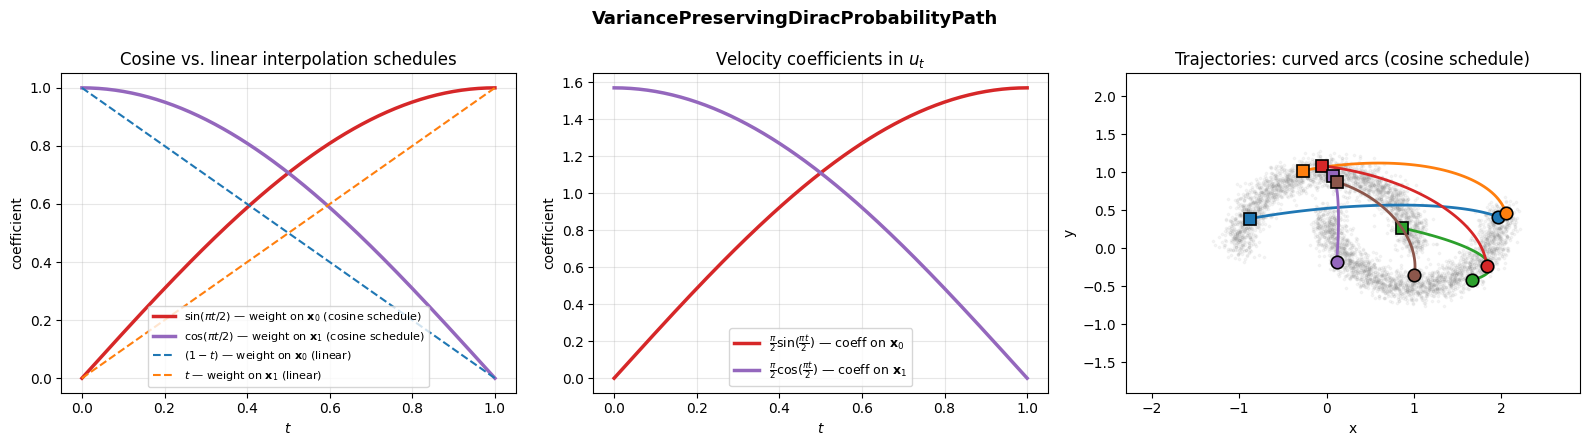

In [25]:
PAIR_COLORS = [plt.cm.tab10(i / 10) for i in range(n_pairs)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(
    t_vals, coeff_x0_vp, lw=2.5, color="tab:red", label=r"$\sin(\pi t/2)$ — weight on $\mathbf{x}_0$ (cosine schedule)"
)
axes[0].plot(
    t_vals,
    coeff_x1_vp,
    lw=2.5,
    color="tab:purple",
    label=r"$\cos(\pi t/2)$ — weight on $\mathbf{x}_1$ (cosine schedule)",
)
axes[0].plot(
    t_vals, 1 - t_vals, lw=1.5, color="tab:blue", linestyle="--", label=r"$(1-t)$ — weight on $\mathbf{x}_0$ (linear)"
)
axes[0].plot(
    t_vals, t_vals, lw=1.5, color="tab:orange", linestyle="--", label=r"$t$ — weight on $\mathbf{x}_1$ (linear)"
)
axes[0].set_xlabel("$t$")
axes[0].set_ylabel("coefficient")
axes[0].set_title("Cosine vs. linear interpolation schedules")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(
    t_vals,
    vel_coeff_x0_vp,
    lw=2.5,
    color="tab:red",
    label=r"$\frac{\pi}{2}\sin(\frac{\pi t}{2})$ — coeff on $\mathbf{x}_0$",
)
axes[1].plot(
    t_vals,
    vel_coeff_x1_vp,
    lw=2.5,
    color="tab:purple",
    label=r"$\frac{\pi}{2}\cos(\frac{\pi t}{2})$ — coeff on $\mathbf{x}_1$",
)
axes[1].set_xlabel("$t$")
axes[1].set_ylabel("coefficient")
axes[1].set_title(r"Velocity coefficients in $u_t$")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

axes[2].scatter(bottom_moon_X[:, 0], bottom_moon_X[:, 1], s=3, alpha=0.07, color="gray")
axes[2].scatter(top_moon_X[:, 0], top_moon_X[:, 1], s=3, alpha=0.07, color="gray")
for i, traj in enumerate(trajs_vp):
    color = PAIR_COLORS[i]
    axes[2].plot(traj[:, 0], traj[:, 1], "-", color=color, lw=2)
    axes[2].plot(*x0_batch_vp[i].numpy(), "o", color=color, ms=9, markeredgecolor="k", mew=1.2)
    axes[2].plot(*x1_batch_vp[i].numpy(), "s", color=color, ms=9, markeredgecolor="k", mew=1.2)
axes[2].set_xlim(-2.3, 2.9)
axes[2].set_ylim(-1.9, 2.3)
axes[2].set_title("Trajectories: curved arcs (cosine schedule)")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")

plt.suptitle("VariancePreservingDiracProbabilityPath", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 5. Side-by-Side Comparison with SCFlow

Each path plugs directly into `SCFlow` via the `probability_path=` argument.
The rest of the model — architecture, ODE solver, predict API — is unchanged.

```python
model = SCFlow(
    method_id="cfm",
    backend="torch",
    probability_path=SchrodingerBridgeProbabilityPath(sigma=0.2),  # ← swap path here
    vf_decoder_mlp_kwargs={"hidden_dims": [32, 32]},
)
```

**Default:** when `probability_path` is omitted, CFM uses `LinearDiracProbabilityPath()`.

Below we train a separate generative model (noise → top moon) for each path and compare the generated samples side by side.

In [26]:
import pandas as pd

n_target = top_moon_X.shape[0]
n_noise = 500

# explicit string indices to avoid AnnData ImplicitModificationWarning
adata_target = ad.AnnData(X=top_moon_X.numpy(), obs=pd.DataFrame(index=[str(i) for i in range(n_target)]))
SCFlow.register_adata(adata_target)

np.random.seed(0)
adata_noise = ad.AnnData(
    X=np.random.randn(n_noise, 2).astype(np.float32), obs=pd.DataFrame(index=[str(i) for i in range(n_noise)])
)

In [29]:
path_configs = {
    "LinearDirac": LinearDiracProbabilityPath(),
    "LinearGaussian sigma=0.2": LinearGaussianProbabilityPath(sigma=0.2, prng=torch.Generator()),
    "SchrodingerBridge sigma=0.2": SchrodingerBridgeProbabilityPath(sigma=0.2, prng=torch.Generator()),
    "VariancePreserving": VariancePreservingDiracProbabilityPath(),
}

generated = {}
for name, path in path_configs.items():
    torch.manual_seed(42)
    model = SCFlow(
        method_id="cfm",
        backend="torch",
        generate_from_noise=True,
        probability_path=path,
        vf_decoder_mlp_kwargs={"hidden_dims": [32, 32]},
    )
    model.train(adata_target, n_train_steps=2_000, train_batch_size=256, optim_kwargs={"lr": 1e-3})
    adata_pred = model.predict(adata_noise, num_steps=20)
    generated[name] = np.array(adata_pred.X)
    print(f"  {name.splitlines()[0]} Done")

100%|██████████| 1/1 [00:00<00:00, 2845.53it/s]
| loss:0.7986 | step:2000: 100%|██████████| 2000/2000 [00:09<00:00, 205.39it/s]
Predicting: 100%|██████████| 1/1 [00:00<00:00, 30.90it/s]


  LinearDirac Done


100%|██████████| 1/1 [00:00<00:00, 2264.74it/s]
| loss:0.8577 | step:2000: 100%|██████████| 2000/2000 [00:11<00:00, 170.85it/s]
Predicting: 100%|██████████| 1/1 [00:00<00:00, 52.19it/s]


  LinearGaussian sigma=0.2 Done


100%|██████████| 1/1 [00:00<00:00, 2228.64it/s]
| loss:0.8053 | step:2000: 100%|██████████| 2000/2000 [00:08<00:00, 222.70it/s]
Predicting: 100%|██████████| 1/1 [00:00<00:00, 42.27it/s]


  SchrodingerBridge sigma=0.2 Done


100%|██████████| 1/1 [00:00<00:00, 1489.45it/s]
| loss:1.0069 | step:2000: 100%|██████████| 2000/2000 [00:08<00:00, 249.06it/s]
Predicting: 100%|██████████| 1/1 [00:00<00:00, 44.25it/s]

  VariancePreserving Done


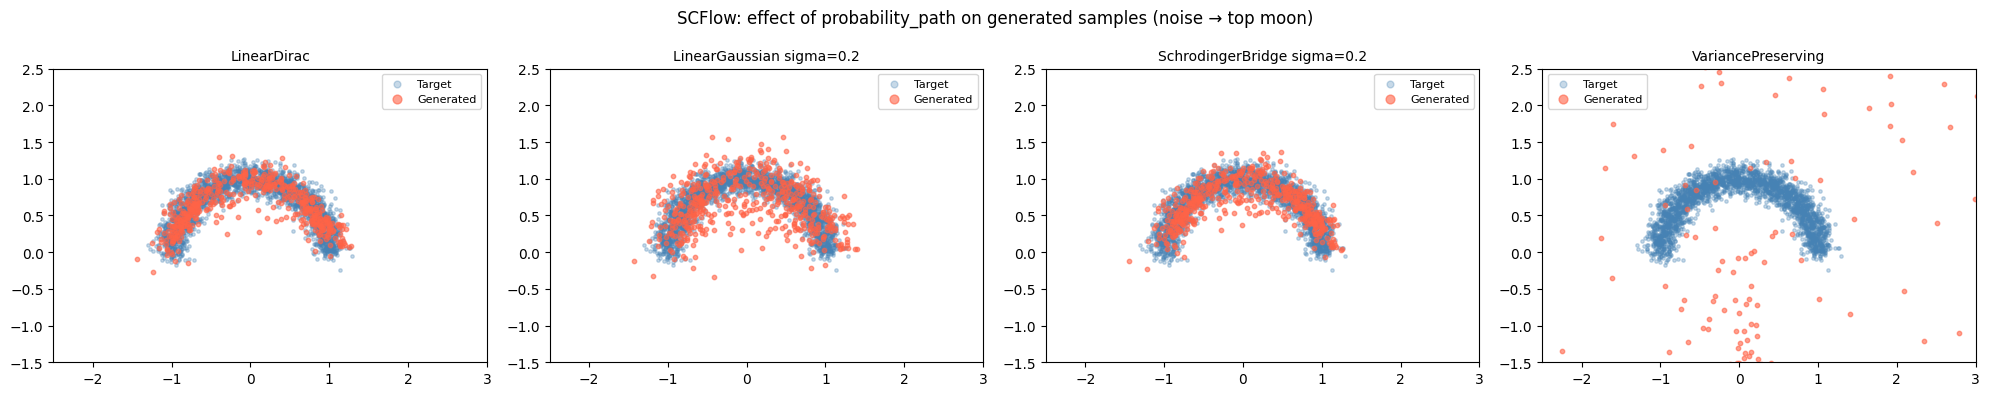

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, pts) in zip(axes, generated.items(), strict=True):
    ax.scatter(top_moon_X[:, 0], top_moon_X[:, 1], s=6, color="steelblue", alpha=0.3, label="Target")
    ax.scatter(pts[:, 0], pts[:, 1], s=10, color="tomato", alpha=0.6, label="Generated")
    ax.set_title(name, fontsize=10)
    ax.set_xlim(-2.5, 3.0)
    ax.set_ylim(-1.5, 2.5)
    ax.legend(fontsize=8, markerscale=2)
plt.suptitle("SCFlow: effect of probability_path on generated samples (noise → top moon)", fontsize=12)
plt.tight_layout()
plt.show()

---
## 6. Custom Path: Stochastic Interpolant

A **non-linear interpolation** path where the weight on the target grows quadratically in time.
The path starts slowly near the source and accelerates toward the target in the second half of the trajectory.

**Non-linear interpolation**

$$\mu_t(\mathbf{x}_0, \mathbf{x}_1) = (1-t)\,\mathbf{x}_0 + t^2\,\mathbf{x}_1$$

The $t^2$ weight on $\mathbf{x}_1$ delays the path's commitment to the target compared to the linear $t$ weight used by the four built-in paths.

**Noise standard deviation**

$$\sigma_t = \sigma\,(1-t)$$

Noise is largest at $t=0$ and decays linearly to zero at $t=1$ — the endpoint is always exact.
Unlike the Schrödinger Bridge ($\sigma_t$ vanishes at both ends), only the right endpoint is deterministic here.

**Conditional velocity field**

$$u_t(\mathbf{x}_t \mid \mathbf{x}_0, \mathbf{x}_1)
  = -\mathbf{x}_0 + 2t\,\mathbf{x}_1
    - \frac{\mathbf{x}_t - \mu_t}{1 - t + \varepsilon}$$

The first two terms are $\tfrac{d}{dt}\mu_t$ — the deterministic drift.
The third term is a noise correction: as $t \to 1$ it grows large and pulls any noisy $\mathbf{x}_t$ back toward $\mu_t = \mathbf{x}_1$.
The $\varepsilon$ floor prevents division by zero.

**Parameters**

| Parameter | Type | Default | Description |
|---|---|---|---|
| `sigma` | `float` | *required* | Controls the initial noise level. $\sigma_0 = \sigma$ at $t=0$, decaying to $0$ at $t=1$. |
| `eps` | `float` | `1e-35` | Added to the denominator $1-t$ to avoid division by zero near $t=1$. |

> **References:** \[7\] Albergo, M. S., & Vanden-Eijnden, E. (2023). **Stochastic Interpolants: A Unifying Framework for Flows and Diffusions.** [https://arxiv.org/abs/2303.08797](https://arxiv.org/abs/2303.08797)

This path is not built into `sc_flow` — we define the class inline and pass the instance directly to `SCFlow`.

In [34]:
from sc_flow.backends.torch.probability_paths import BaseProbabilityPath
from sc_flow.backends.torch._utils import broadcast_to_target_shape


class StochasticInterpolantProbabilityPath(BaseProbabilityPath):
    """Stochastic Interpolant path

    Non-linear mean:  mu_t  = (1-t)*x0 + t^2*x1
    Noise decay:      sigma_t = sigma*(1-t)   (zero at t=1)
    Velocity field:   u_t = -x0 + 2t*x1 - (xt - mu_t)/(1-t+eps)
    """

    _require_prng: bool = True

    def __init__(self, sigma: float, prng: torch.Generator | None = None, eps: float = 1e-35) -> None:
        """Set noise level, PRNG, and the epsilon floor for the velocity denominator."""
        self._eps = eps
        super().__init__(sigma=sigma, prng=prng)

    def compute_mu_t(self, t: torch.Tensor, x0: torch.Tensor, x1: torch.Tensor) -> torch.Tensor:
        """Return the path mean (1-t)*x0 + t^2*x1 at time t."""
        t = broadcast_to_target_shape(t, x0.shape)
        self._verify_shapes(x0, x1)
        self._verify_shapes(t, x1)
        return (1 - t) * x0 + t**2 * x1

    def compute_sigma_t(self, t: torch.Tensor) -> torch.Tensor:
        """Return the noise std sigma*(1-t), which decays linearly to zero at t=1."""
        return self._sigma * (1 - t)

    def compute_ut(self, t: torch.Tensor, xt: torch.Tensor, x0: torch.Tensor, x1: torch.Tensor) -> torch.Tensor:
        """Return the conditional velocity field: deterministic drift plus a noise-correction term."""
        t = broadcast_to_target_shape(t, x0.shape)
        self._verify_shapes(xt, x1)
        self._verify_shapes(x0, x1)
        self._verify_shapes(t, x1)
        mu_t = self.compute_mu_t(t, x0, x1)
        return -x0 + 2 * t * x1 - (xt - mu_t) / (1 - t + self._eps)


# Test
si_path = StochasticInterpolantProbabilityPath(sigma=0.2, prng=torch.Generator())
t = torch.tensor([0.5])
x0_test = torch.randn(4, 2)
x1_test = torch.randn(4, 2)
xt_test = si_path.compute_xt(t, x0_test, x1_test)
ut_test = si_path.compute_ut(t, xt_test, x0_test, x1_test)
print(f"xt shape: {xt_test.shape}   ut shape: {ut_test.shape}")

xt shape: torch.Size([4, 2])   ut shape: torch.Size([4, 2])


The probability path  StochasticInterpolantProbabilityPath requires a PRNG. Please provide an instance of `torch.Generator`for reproducible results. Setting it to \`torch.random.default_generator\` by default.


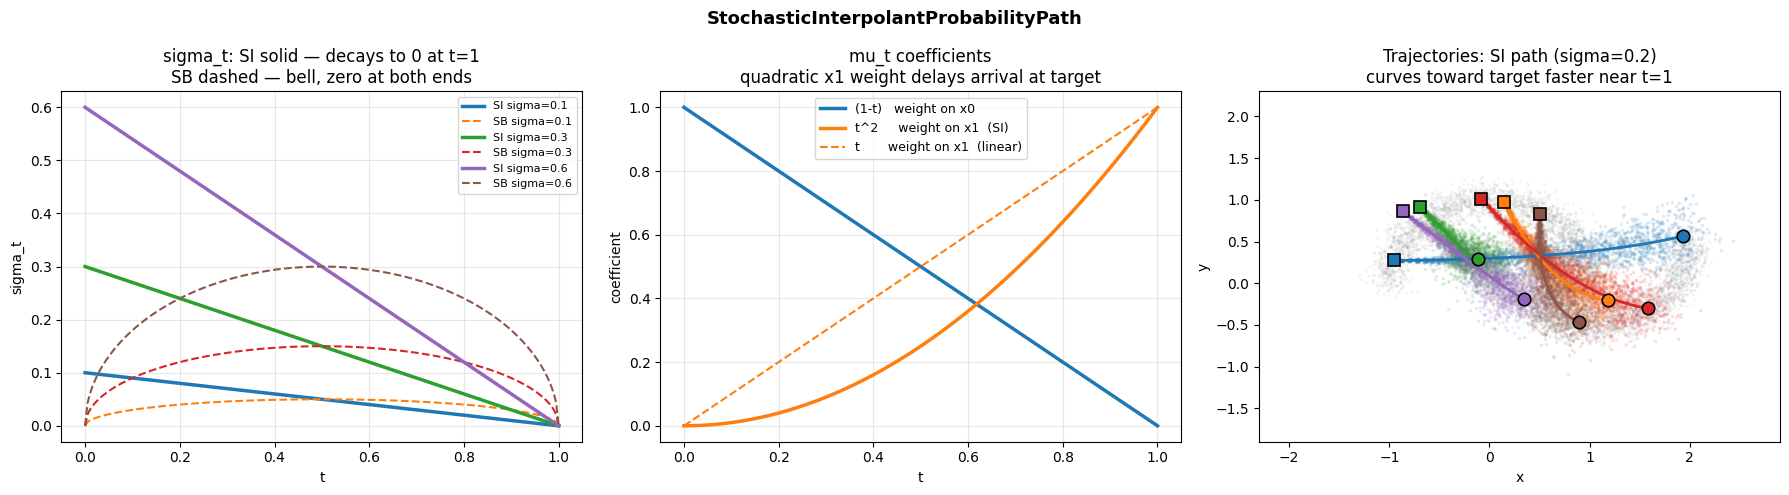

In [ ]:
t_vals = np.linspace(0, 1, 200)
SIGMAS = [0.1, 0.3, 0.6]

# Calculate sigma_t
_t = torch.tensor(t_vals, dtype=torch.float32)

sigma_t_si = {}
for sigma in SIGMAS:
    path = StochasticInterpolantProbabilityPath(sigma=sigma, prng=torch.Generator())
    sigma_t_si[sigma] = path.compute_sigma_t(_t).detach().numpy()

sigma_t_sb_ref = {}
for sigma in SIGMAS:
    path = SchrodingerBridgeProbabilityPath(sigma=sigma, prng=torch.Generator())
    sigma_t_sb_ref[sigma] = path.compute_sigma_t(_t).numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -- sigma_t: SI (linear decay) vs SB (bell curve)
for sigma in SIGMAS:
    axes[0].plot(t_vals, sigma_t_si[sigma], lw=2.5, label=f"SI sigma={sigma}")
    axes[0].plot(t_vals, sigma_t_sb_ref[sigma], lw=1.5, linestyle="--", label=f"SB sigma={sigma}")
axes[0].set_xlabel("t")
axes[0].set_ylabel("sigma_t")
axes[0].set_title("sigma_t: SI solid — decays to 0 at t=1\nSB dashed — bell, zero at both ends")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# -- mu_t coefficients: quadratic x1 weight vs linear
axes[1].plot(t_vals, 1 - t_vals, lw=2.5, color="tab:blue", label="(1-t)   weight on x0")
axes[1].plot(t_vals, t_vals**2, lw=2.5, color="tab:orange", label="t^2     weight on x1  (SI)")
axes[1].plot(t_vals, t_vals, lw=1.5, color="tab:orange", linestyle="--", label="t       weight on x1  (linear)")
axes[1].set_xlabel("t")
axes[1].set_ylabel("coefficient")
axes[1].set_title("mu_t coefficients\nquadratic x1 weight delays arrival at target")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# -- sample trajectories
torch.manual_seed(7)
n_pairs = 6
src_idx = torch.randperm(len(bottom_moon_X))[:n_pairs]
tgt_idx = torch.randperm(len(top_moon_X))[:n_pairs]
x0_batch_si = bottom_moon_X[src_idx]
x1_batch_si = top_moon_X[tgt_idx]
T_STEPS = torch.linspace(0, 1, 50)
N_NOISE = 40

path_si_viz = StochasticInterpolantProbabilityPath(sigma=0.2)
axes[2].scatter(bottom_moon_X[:, 0], bottom_moon_X[:, 1], s=2, alpha=0.05, color="gray")
axes[2].scatter(top_moon_X[:, 0], top_moon_X[:, 1], s=2, alpha=0.05, color="gray")
for i in range(n_pairs):
    color = plt.cm.tab10(i / 10)
    x0i, x1i = x0_batch_si[i : i + 1], x1_batch_si[i : i + 1]
    traj = np.array([path_si_viz.compute_mu_t(t * torch.ones(1), x0i, x1i).numpy()[0] for t in T_STEPS])
    cloud = np.array(
        [
            path_si_viz.compute_xt(t * torch.ones(1), x0i, x1i).detach().numpy()[0]
            for t in T_STEPS
            for _ in range(N_NOISE)
        ]
    )
    axes[2].scatter(cloud[:, 0], cloud[:, 1], s=6, color=color, alpha=0.15, linewidths=0)
    axes[2].plot(traj[:, 0], traj[:, 1], "-", color=color, lw=2, zorder=3)
    axes[2].plot(*x0_batch_si[i].numpy(), "o", color=color, ms=9, markeredgecolor="k", mew=1.2, zorder=5)
    axes[2].plot(*x1_batch_si[i].numpy(), "s", color=color, ms=9, markeredgecolor="k", mew=1.2, zorder=5)
axes[2].set_xlim(-2.3, 2.9)
axes[2].set_ylim(-1.9, 2.3)
axes[2].set_title("Trajectories: SI path (sigma=0.2)\ncurves toward target faster near t=1")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")

plt.suptitle("StochasticInterpolantProbabilityPath", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

The probability path  StochasticInterpolantProbabilityPath requires a PRNG. Please provide an instance of `torch.Generator`for reproducible results. Setting it to \`torch.random.default_generator\` by default.
100%|██████████| 1/1 [00:00<00:00, 347.38it/s]
| loss:0.6569 | step:2000: 100%|██████████| 2000/2000 [00:14<00:00, 135.75it/s]
Predicting: 100%|██████████| 1/1 [00:00<00:00, 15.34it/s]
C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


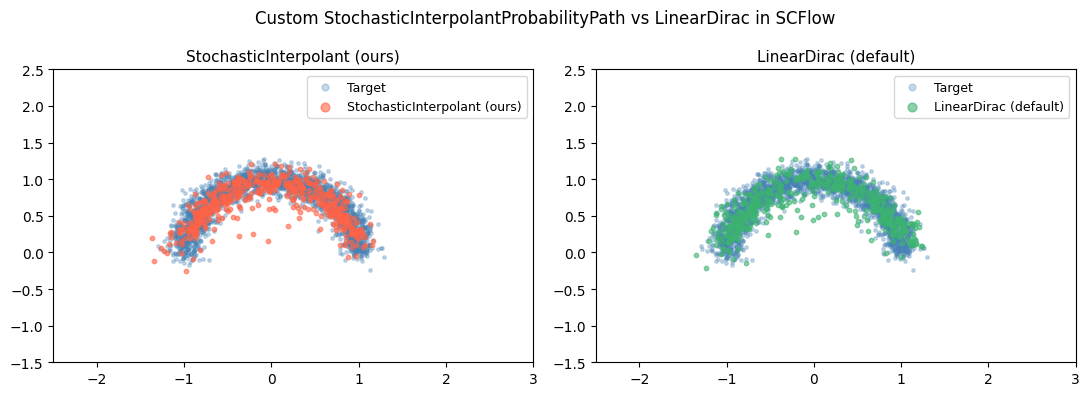

In [ ]:
model_si = SCFlow(
    method_id="cfm",
    backend="torch",
    generate_from_noise=True,
    probability_path=StochasticInterpolantProbabilityPath(sigma=0.2),
    vf_decoder_mlp_kwargs={"hidden_dims": [32, 32]},
)
model_si.train(adata_target, n_train_steps=2_000, train_batch_size=256, optim_kwargs={"lr": 1e-3})
adata_si = model_si.predict(adata_noise, num_steps=20)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (pts, label, color) in zip(
    axes,
    [
        (np.array(adata_si.X), "StochasticInterpolant (ours)", "tomato"),
        (generated["LinearDirac\n(default)"], "LinearDirac (default)", "mediumseagreen"),
    ],
    strict=True,
):
    ax.scatter(top_moon_X[:, 0], top_moon_X[:, 1], s=6, color="steelblue", alpha=0.3, label="Target")
    ax.scatter(pts[:, 0], pts[:, 1], s=10, color=color, alpha=0.6, label=label)
    ax.set_title(label, fontsize=11)
    ax.set_xlim(-2.5, 3.0)
    ax.set_ylim(-1.5, 2.5)
    ax.legend(fontsize=9, markerscale=2)
plt.suptitle("Custom StochasticInterpolantProbabilityPath vs LinearDirac in SCFlow", fontsize=12)
plt.tight_layout()
plt.show()

---
## References

\[1\] Lipman, Y., Chen, R. T. Q., Ben-Hamu, H., Nickel, M., & Le, M. (2022).
**Flow Matching for Generative Modeling.** *ICLR 2023.*
[https://arxiv.org/abs/2210.02747](https://arxiv.org/abs/2210.02747)

\[2\] Liu, X., Gong, C., & Liu, Q. (2022).
**Flow Straight and Fast: Learning to Generate and Transfer Data with Rectified Flow.** *ICLR 2023.*
[https://arxiv.org/abs/2209.03003](https://arxiv.org/abs/2209.03003)

\[3\] Tong, A., Malkin, N., Huguet, G., Zhang, Y., Rector-Brooks, J., Fatras, K., Wolf, G., & Bengio, Y. (2023).
**Improving and Generalizing Flow-Matching for Conditional Generation (CFM).** *ICML 2024.*
[https://arxiv.org/abs/2302.00482](https://arxiv.org/abs/2302.00482)

\[4\] Tong, A., De Bortoli, V., Doucet, A., & Durmus, A. (2023).
**Simulation-Free Schrödinger Bridges via Score and Flow Matching (SFBM).**
[https://arxiv.org/abs/2307.03672](https://arxiv.org/abs/2307.03672)

\[5\] Albergo, M. S., & Vanden-Eijnden, E. (2022).
**Building Normalizing Flows with Stochastic Interpolants.** *ICLR 2023.*
[https://arxiv.org/abs/2209.15571](https://arxiv.org/abs/2209.15571)

\[6\] Song, Y., Sohl-Dickstein, J., Kingma, D. P., Kumar, A., Ermon, S., & Poole, B. (2020).
**Score-Based Generative Modeling through Stochastic Differential Equations (VP-SDE).** *ICLR 2021.*
[https://arxiv.org/abs/2011.13456](https://arxiv.org/abs/2011.13456)
